# Synthetic Graph Dynamics with KoopmanGraph

This notebook walks through an end-to-end workflow on a reproducible synthetic
spatiotemporal graph benchmark. We fit a **GraphKoopmanModel** (encode →
Koopman step → decode) and evaluate open-loop rollouts on held-out origins.

Koopman operator theory represents nonlinear dynamics as linear evolution in a
lifted (observable) space. KoopmanGraph combines that idea with Graph Neural
Networks so the lifting and decoding steps respect graph structure.

**Evaluation protocol.** We use a chronological `temporal_split`, train only on
the earlier prefix, and score multi-horizon forecasts on the held-out test
window with the public `model.evaluate` façade — plus a persistence
(last-observation) baseline so skill is not overstated. On this nearly linear
diffusion benchmark, beating persistence is **not** guaranteed.


## The encode → Koopman step → decode workflow

Each prediction step follows three stages:

1. **Encode (lifting):** A GNN encoder maps physical node features
   $x_t \in \mathbb{R}^{N \times F}$ into a latent representation
   $z_t \in \mathbb{R}^{N \times d}$ while passing messages along edges.
2. **Linear advance (Koopman step):** A learned matrix $K$ propagates the
   latent state forward: $z_{t+1} \approx z_t K^\top$ (per node).
3. **Decode:** A symmetric GNN decoder maps $z_{t+1}$ back to predicted
   physical features $\hat{x}_{t+1}$.

Training aligns one-step predictions with observed snapshots and can add
forward-consistency losses so encoded states evolve linearly in latent space.


In [1]:
import tempfile
import warnings
from pathlib import Path

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

# Use a non-interactive backend when no display is available.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import temporal_split
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.training import LossWeights

IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))

# Benchmark
NUM_NODES = 20
NUM_TIMESTEPS = 80
IN_CHANNELS = 3
TOPOLOGY = "path"
DATA_SEED = 42
INITIAL_STATE = "ones"
DECAY_RATE = 0.99
DIFFUSION_RATE = 0.1
NOISE_STD = 0.01

# Model
HIDDEN_CHANNELS = 64
LATENT_DIM = 64
TIME_STEP = 0.1
MODEL_SEED = 0

# Training / evaluation
EPOCHS = 10 if IS_CI else 50
LR = 1e-3
REQUESTED_HORIZONS = (1, 2, 3) if IS_CI else (1, 3, 5, 10)
EARLY_STOPPING_PATIENCE = 20
LOSS_WEIGHTS = LossWeights(
    reconstruction=1.0,
    forward=1.0,
    rollout=1.0,
)

# Plotting
FEATURE_IDX = 0
NODE_IDS = [0, 5, 10, 19]


## Generate synthetic data

`SyntheticDynamicGraphBenchmark` produces a sequence of PyG `Data` snapshots
on a fixed path graph. Node features evolve via Laplacian diffusion with
global decay and optional Gaussian noise:

$$
x_{t+1} = \mathrm{decay\_rate}\cdot S x_t + \mathcal{N}(0, \sigma^2),
\quad
S = (1 - \mathrm{diffusion\_rate})\,I
  + \mathrm{diffusion\_rate}\, D^{-1/2} A D^{-1/2},
$$

where $\sigma$ is the benchmark's `noise_std` (standard deviation). The general
package step uses the isolate-aware Laplacian $L_{\mathrm{sym}} = P - \widehat{A}$;
on a path graph with no isolates this reduces to the displayed
$D^{-1/2} A D^{-1/2}$ form.

We use a uniform initial state with mild decay and diffusion so trajectories
start smoothly instead of showing a sharp first-step transient. The sequence
length (`num_timesteps=80`) is long enough for a chronological train / val /
test split while still supporting multi-origin evaluation at horizon 10.
With `noise_std=0.01`, one-step RMSE near $0.01$ is roughly the noise floor —
persistence can be competitive on this nearly linear benchmark.


In [2]:
data_sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    topology=TOPOLOGY,
    seed=DATA_SEED,
    initial_state=INITIAL_STATE,
    decay_rate=DECAY_RATE,
    diffusion_rate=DIFFUSION_RATE,
    noise_std=NOISE_STD,
)

# Chronological split: train on the prefix; hold out later windows for eval.
split = temporal_split(data_sequence)

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Nodes: {data_sequence.num_nodes}")
print(f"Feature dim: {data_sequence.in_channels}")
print(f"Edges: {data_sequence.edge_index.shape[1]}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")
print(
    "Train / val / test: "
    f"{split.train.num_timesteps} / {split.val.num_timesteps} / "
    f"{split.test.num_timesteps}"
)


Snapshots: 80
Nodes: 20
Feature dim: 3
Edges: 38
First snapshot shape: torch.Size([20, 3])
Train / val / test: 56 / 8 / 16


Plot a few node trajectories for feature 0. Vertical markers show the
chronological `temporal_split`: train on the left prefix, validate in the
middle band, and score forecasts only on the held-out test window to the right.


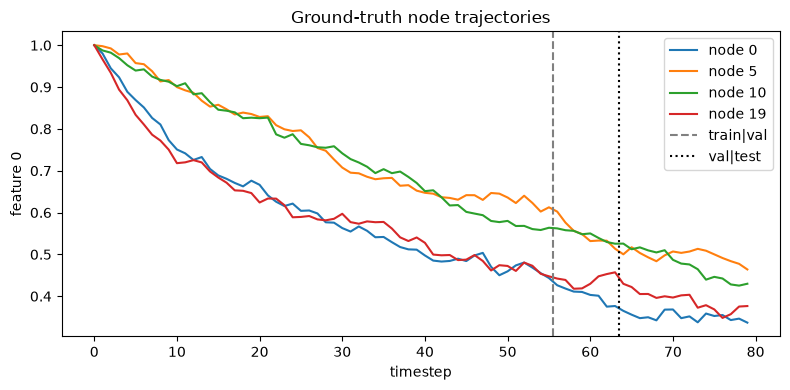

In [3]:
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for node_id in NODE_IDS:
    values = torch.stack([snap.x[node_id, FEATURE_IDX] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"node {node_id}")
ax.axvline(split.train.num_timesteps - 0.5, color="gray", linestyle="--", label="train|val")
ax.axvline(
    split.train.num_timesteps + split.val.num_timesteps - 0.5,
    color="black",
    linestyle=":",
    label="val|test",
)
ax.set_xlabel("timestep")
ax.set_ylabel(f"feature {FEATURE_IDX}")
ax.set_title("Ground-truth node trajectories")
ax.legend()
fig.tight_layout()
plt.show()


## Build the model

We compose a GCN encoder, a learnable Koopman operator (inside
`GraphKoopmanModel`), and a symmetric GCN decoder.

`time_step` is a required constructor argument that records the uniform
sampling interval associated with each discrete Koopman advance. This
benchmark advances one integer snapshot per step, so any positive value is
valid metadata; we use `0.1` to match the package quickstart.

We call `torch.manual_seed(MODEL_SEED)` immediately before constructing modules
so weight initialization is fixed across Restart & Run All (`MODEL_SEED` is set
in the setup cell).


In [4]:
in_channels = data_sequence.in_channels
out_channels = in_channels

# Seed before constructing modules so initial weights are reproducible.
torch.manual_seed(MODEL_SEED)
encoder = GNNEncoder(in_channels, HIDDEN_CHANNELS, LATENT_DIM)
decoder = GNNDecoder(LATENT_DIM, HIDDEN_CHANNELS, out_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT_DIM,
    time_step=TIME_STEP,
)

print(model)


GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(3, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 3)
    )
  )
  (koopman): KoopmanOperator()
)


## Train

`fit` optimizes one-step reconstruction, forward consistency in latent
space, and an autoregressive rollout term that matches open-loop `predict`.
If you evaluate with teacher-forced one-step predictions only, a large
rollout weight is less critical; here evaluation uses open-loop rollouts, so
a nonzero rollout term is the matching training signal (not a universal rule
that rollout must always be 1.0).

We train **only** on `split.train` (with `split.val` for early stopping).
The loss curve below is a **fit diagnostic** — it is not a holdout forecast
claim. Near-zero train/val loss does not imply holdout skill versus persistence
on this near-linear, noise-floor problem; that comparison is in the next
section via multi-origin `model.evaluate` on `split.test`.

Because validation is short (`T_val=8` under the default split), the training
`rollout_horizon` is capped at `T_val - 1` even when test evaluation uses a
longer max horizon (e.g. 10).


In [5]:
# Horizons that fit the chronological test window (T_test - 1).
max_eval_horizon = split.test.num_timesteps - 1
eval_horizons = tuple(h for h in REQUESTED_HORIZONS if h <= max_eval_horizon)
if not eval_horizons:
    raise ValueError(
        f"test split has {split.test.num_timesteps} timesteps; "
        f"need at least {min(REQUESTED_HORIZONS) + 1} for evaluation"
    )
predict_steps = max(eval_horizons)
rollout_horizon = min(
    predict_steps,
    min(split.train.num_timesteps, split.val.num_timesteps) - 1,
)

history = model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
    loss_weights=LOSS_WEIGHTS,
    rollout_horizon=rollout_horizon,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
)

print(f"Eval horizons: {eval_horizons}")
print(f"Initial train loss: {history.loss[0]:.6f}")
print(f"Final train loss: {history.loss[-1]:.6f}")
if history.val_loss is not None:
    best_val_epoch = history.val_loss.index(min(history.val_loss))
    print(f"Final val loss: {history.val_loss[-1]:.6f}")
    print(f"Best validation epoch: {best_val_epoch}")


Eval horizons: (1, 3, 5, 10)
Initial train loss: 2.080076
Final train loss: 0.007257
Final val loss: 0.006242
Best validation epoch: 44


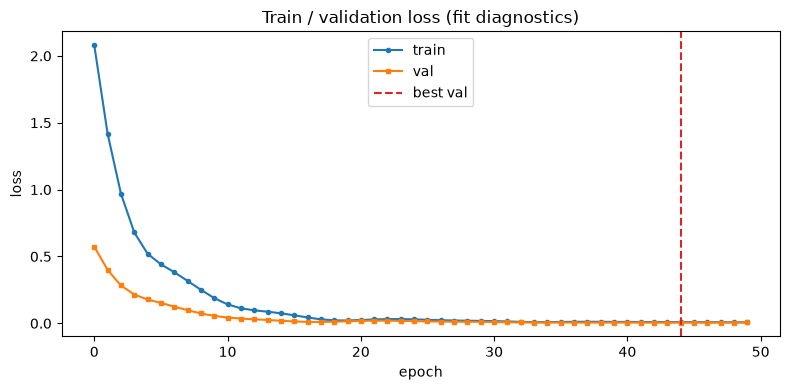

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.loss, marker="o", markersize=3, label="train")
if history.val_loss is not None:
    ax.plot(history.val_loss, marker="s", markersize=3, label="val")
    best_val_epoch = history.val_loss.index(min(history.val_loss))
    ax.axvline(best_val_epoch, color="C3", linestyle="--", label="best val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Train / validation loss (fit diagnostics)")
ax.legend()
fig.tight_layout()
plt.show()


## Evaluate on the held-out test split

`model.evaluate` reports MAE and RMSE at the requested horizons, averaged over
**all valid forecast origins** in the chronological test window. That
multi-origin, **exact-horizon** protocol is the primary accuracy claim
(error at step $h$, not the mean over steps $1\ldots h$).

We also score a **persistence** baseline (repeat the last observation) with the
**same shared origins** (those valid for the max horizon) and the same
exact-horizon RMSE definition as `model.evaluate`. On Laplacian diffusion with
mild noise, persistence is often competitive — at horizon 1 it sits near the
`noise_std=0.01` floor — so beating it is not guaranteed for this short
tutorial budget.

With the data seed and `torch.manual_seed(MODEL_SEED)` before model
construction, Restart & Run All is bit-reproducible on CPU. The single-origin
rollout panels (bottom of the next figure) are for illustration only —
multi-origin RMSE is the claim.


In [7]:
def exact_horizon_rmse(
    predict_fn,
    test_seq,
    horizons: tuple[int, ...],
    *,
    start_indices: list[int],
) -> dict[int, float]:
    """Exact-horizon RMSE matching ``model.evaluate`` (mean of per-origin RMSE)."""
    scores: dict[int, float] = {}
    for horizon in horizons:
        origin_rmses: list[torch.Tensor] = []
        for origin in start_indices:
            preds = predict_fn(test_seq[origin], horizon)
            origin_rmses.append(
                (preds[horizon - 1].x - test_seq[origin + horizon].x)
                .pow(2)
                .mean()
                .sqrt()
            )
        scores[horizon] = float(torch.stack(origin_rmses).mean())
    return scores


def persistence_predict(snapshot: Data, steps: int) -> list[Data]:
    return [
        Data(x=snapshot.x.clone(), edge_index=snapshot.edge_index)
        for _ in range(steps)
    ]


# Match evaluate_forecast: only origins valid for the max requested horizon.
max_horizon = max(eval_horizons)
eval_origins = list(range(0, split.test.num_timesteps - max_horizon))
if not eval_origins:
    raise ValueError(
        f"test split has {split.test.num_timesteps} timesteps; "
        f"need at least {max_horizon + 1} for evaluation"
    )

result = model.evaluate(
    split.test, horizons=eval_horizons, start_indices=eval_origins
)
persist_rmses = exact_horizon_rmse(
    persistence_predict,
    split.test,
    eval_horizons,
    start_indices=eval_origins,
)
graph_rmses = {m.horizon: m.rmse for m in result.horizons}

print(
    f"Multi-origin test metrics "
    f"({result.num_origins} shared origins, max horizon={max_horizon})"
)
print(f"{'horizon':>8} {'MAE':>10} {'RMSE':>10} {'persist RMSE':>14}")
for metric in result.horizons:
    print(
        f"{metric.horizon:>8} {metric.mae:>10.4f} {metric.rmse:>10.4f} "
        f"{persist_rmses[metric.horizon]:>14.4f}"
    )
print(
    "Aggregate over horizons: "
    f"MAE={result.aggregate_mae:.4f}, RMSE={result.aggregate_rmse:.4f}"
)

beats = sum(1 for h in eval_horizons if graph_rmses[h] < persist_rmses[h])
if beats == len(eval_horizons):
    print("GraphKoopman beats persistence on all reported horizons.")
elif beats == 0:
    print(
        "Persistence matches or beats GraphKoopman on all reported horizons "
        "(common on this nearly linear diffusion benchmark)."
    )
else:
    print(
        f"GraphKoopman beats persistence on {beats}/{len(eval_horizons)} "
        "horizons."
    )

# Single test-origin rollout for the figure panels (not the primary claim).
initial_graph = split.test[0]
future_graphs = model.predict(initial_graph, steps=predict_steps)
ground_truth = [split.test[t] for t in range(1, predict_steps + 1)]
step_mse = torch.stack(
    [
        torch.mean((pred.x - truth.x) ** 2)
        for pred, truth in zip(future_graphs, ground_truth, strict=True)
    ]
)
print(
    f"Single test-origin MSE over {predict_steps} steps "
    f"(plotting only): {float(step_mse.mean()):.6f}"
)


Multi-origin test metrics (6 shared origins, max horizon=10)
 horizon        MAE       RMSE   persist RMSE
       1     0.0292     0.0363         0.0119
       3     0.0275     0.0354         0.0234
       5     0.0349     0.0440         0.0331
      10     0.1039     0.1161         0.0552
Aggregate over horizons: MAE=0.0489, RMSE=0.0579
Persistence matches or beats GraphKoopman on all reported horizons (common on this nearly linear diffusion benchmark).
Single test-origin MSE over 10 steps (plotting only): 0.003641


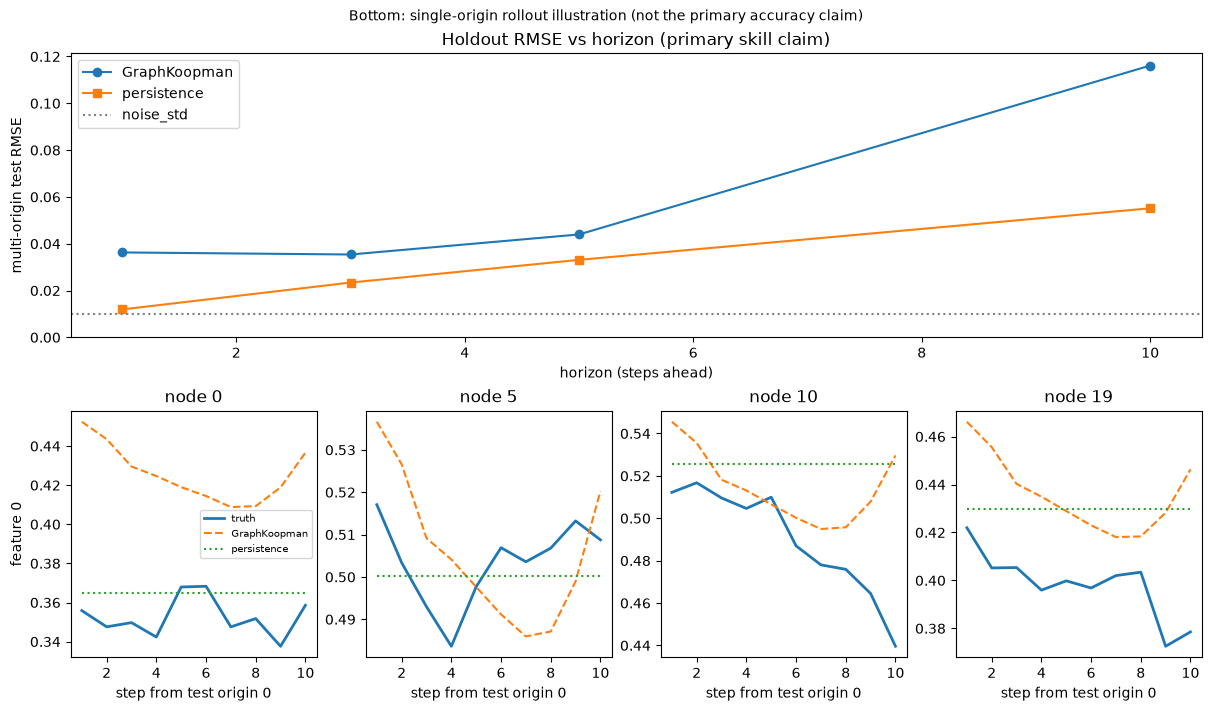

In [8]:
pred_times = torch.arange(1, predict_steps + 1).numpy()
horizon_list = list(eval_horizons)
persist_rollout = persistence_predict(initial_graph, predict_steps)

fig = plt.figure(figsize=(12, 7), layout="constrained")
gs = fig.add_gridspec(2, 4, height_ratios=[1.15, 1.0])

ax_rmse = fig.add_subplot(gs[0, :])
ax_rmse.plot(
    horizon_list,
    [graph_rmses[h] for h in horizon_list],
    marker="o",
    label="GraphKoopman",
)
ax_rmse.plot(
    horizon_list,
    [persist_rmses[h] for h in horizon_list],
    marker="s",
    label="persistence",
)
ax_rmse.axhline(NOISE_STD, color="gray", linestyle=":", label="noise_std")
ax_rmse.set_xlabel("horizon (steps ahead)")
ax_rmse.set_ylabel("multi-origin test RMSE")
ax_rmse.set_title("Holdout RMSE vs horizon (primary skill claim)")
ax_rmse.set_ylim(bottom=0.0)
ax_rmse.legend(loc="upper left")

for col, node_id in enumerate(NODE_IDS):
    ax = fig.add_subplot(gs[1, col])
    truth_values = torch.stack(
        [graph.x[node_id, FEATURE_IDX] for graph in ground_truth]
    ).numpy()
    pred_values = torch.stack(
        [graph.x[node_id, FEATURE_IDX] for graph in future_graphs]
    ).numpy()
    persist_values = torch.stack(
        [graph.x[node_id, FEATURE_IDX] for graph in persist_rollout]
    ).numpy()
    ax.plot(pred_times, truth_values, color="C0", linewidth=2, label="truth")
    ax.plot(
        pred_times, pred_values, color="C1", linestyle="--", label="GraphKoopman"
    )
    ax.plot(
        pred_times, persist_values, color="C2", linestyle=":", label="persistence"
    )
    series_min = min(truth_values.min(), pred_values.min(), persist_values.min())
    series_max = max(truth_values.max(), pred_values.max(), persist_values.max())
    pad = 0.05 * max(series_max - series_min, 1e-3)
    ax.set_ylim(series_min - pad, series_max + pad)
    ax.set_title(f"node {node_id}")
    ax.set_xlabel("step from test origin 0")
    if col == 0:
        ax.set_ylabel(f"feature {FEATURE_IDX}")
        ax.legend(fontsize=7, loc="best")

fig.suptitle(
    "Bottom: single-origin rollout illustration (not the primary accuracy claim)",
    fontsize=10,
)
plt.show()


## Save and reload the trained model

`GraphKoopmanModel.save` writes learned weights **and** encoder/decoder
architecture configuration to a versioned `.pt` checkpoint.
`GraphKoopmanModel.load` reconstructs a ready-to-use model without manually
re-instantiating `GNNEncoder` / `GNNDecoder` classes.

The round-trip below checks that reloaded predictions match the original model.


In [9]:
with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = Path(tmpdir) / "synthetic_model.pt"
    model.save(checkpoint_path)

    loaded_model = GraphKoopmanModel.load(checkpoint_path)
    reloaded_graphs = loaded_model.predict(initial_graph, steps=predict_steps)

max_delta = torch.max(
    torch.stack(
        [
            torch.max(torch.abs(original.x - reloaded.x))
            for original, reloaded in zip(future_graphs, reloaded_graphs, strict=True)
        ]
    )
)
print(f"Checkpoint: {checkpoint_path.name}")
print(f"Max |original - reloaded prediction|: {max_delta.item():.3e}")


Checkpoint: synthetic_model.pt
Max |original - reloaded prediction|: 0.000e+00


## Takeaways

- **Holdout result:** On the chronological test window, multi-origin
  exact-horizon RMSE from `model.evaluate` (table above / top panel) is higher
  than persistence at every reported horizon (1 / 3 / 5 / 10 in the full run).
  At horizon 1, persistence sits near the `noise_std=0.01` floor; the briefly
  trained GraphKoopman model does **not** beat persistence here.
- **What this does *not* show:** No claim of generalization beyond this split,
  seed, and tutorial budget. Restart & Run All is bit-reproducible on CPU with
  the fixed data and model seeds from the setup cell. The bottom rollout panels
  are a single test origin and can show uneven node-wise drift — they are
  illustration, not the primary accuracy claim.
- **Figures:** Prefer the top holdout RMSE-vs-horizon curve (model vs
  persistence) for the skill claim. The bottom node panels are a single test
  origin only — they illustrate open-loop drift versus truth and persistence,
  not multi-origin accuracy.
- **Rollout loss:** Because evaluation uses open-loop `predict`, training with
  a matching nonzero rollout term is the consistent choice. One-step-only
  training can look strong on reconstruction yet fail autoregressively — that
  is not a rule to always set `rollout=1.0` in every setting.
- **Benchmark scope:** Laplacian diffusion + decay on a fixed path graph is
  nearly linear. Doing well (or poorly) here does not imply the same outcome
  on traffic / grid / nonlinear tutorials
  ([`03_traffic_network.ipynb`](03_traffic_network.ipynb),
  [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb), and later notebooks).
- **Also:** `GraphKoopmanModel.save` / `load` round-trips weights and
  encoder/decoder configuration (checkpoint cell above). Spectral recovery of
  the known diffusion operator is left to
  [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb).

## Next steps

- See the [quickstart](https://koopmangraph.readthedocs.io/en/latest/quickstart.html)
  for a minimal script version of this workflow, including optional best-epoch
  checkpointing during `fit`.
- See [`07_koopman_spectrum.ipynb`](07_koopman_spectrum.ipynb) for eigenvalues
  and modes of a trained discrete Koopman operator.
- See [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) for the IEEE 118-bus smart grid tutorial.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss weights, early stopping, and encoder variants.
- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for METR-LA traffic
  speed forecasting on a road sensor network.
- See [`05_custom_data.ipynb`](05_custom_data.ipynb) for loading and formatting your
  own graph time-series data.
